In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
data = pd.read_csv("../data/mnist_train.csv", header=None)

In [49]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [50]:
data = np.array(data)
m, n = data.shape # rows, columns

data_train = data.T
Y_train = data_train[0] # array of all labels
X_train = data_train[1:n] / 255 # array of all pixel values

In [51]:
Y_train
X_train.shape

(784, 60000)

In [52]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5

    return W1, b1, W2, b2

def ReLu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    return np.exp(Z) / sum(np.exp(Z))

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLu(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1)) # zero matrix with size of number of samples and number of classes 0 to 9 = 10 = max 9 + 1
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def deriv_ReLu(Z):
    return Z > 0

def back_prop(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1/m * dZ2.dot(A1.T)
    db2 = 1/m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * deriv_ReLu(Z1)
    dW1 = 1/m * dZ1.dot(X.T)
    db1 = 1/m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [53]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 50 == 0:
            print("Iteration: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))
    return W1, b1, W2, b2

In [54]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 500, 0.5)

Iteration:  0
[9 7 7 ... 7 0 6] [5 0 4 ... 5 6 8]
Accuracy:  0.09256666666666667
Iteration:  50
[3 0 4 ... 5 0 0] [5 0 4 ... 5 6 8]
Accuracy:  0.6822
Iteration:  100
[5 0 4 ... 5 6 0] [5 0 4 ... 5 6 8]
Accuracy:  0.8045
Iteration:  150
[5 0 4 ... 5 6 7] [5 0 4 ... 5 6 8]
Accuracy:  0.8463
Iteration:  200
[5 0 4 ... 5 6 7] [5 0 4 ... 5 6 8]
Accuracy:  0.8647166666666667
Iteration:  250
[5 0 4 ... 5 6 7] [5 0 4 ... 5 6 8]
Accuracy:  0.8748333333333334
Iteration:  300
[5 0 4 ... 5 6 2] [5 0 4 ... 5 6 8]
Accuracy:  0.8812833333333333
Iteration:  350
[5 0 4 ... 5 6 2] [5 0 4 ... 5 6 8]
Accuracy:  0.8867166666666667
Iteration:  400
[5 0 4 ... 5 6 8] [5 0 4 ... 5 6 8]
Accuracy:  0.892
Iteration:  450
[5 0 4 ... 5 6 8] [5 0 4 ... 5 6 8]
Accuracy:  0.89765


In [55]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [6]
Label:  6


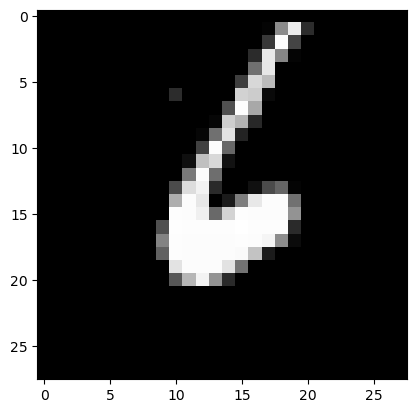

Prediction:  [1]
Label:  1


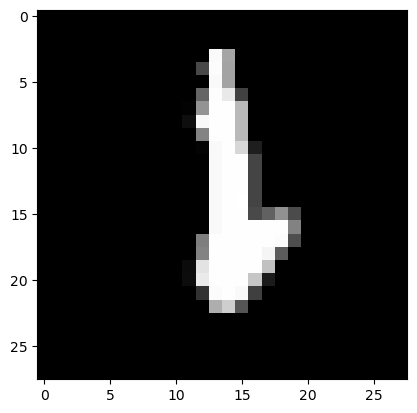

Prediction:  [4]
Label:  4


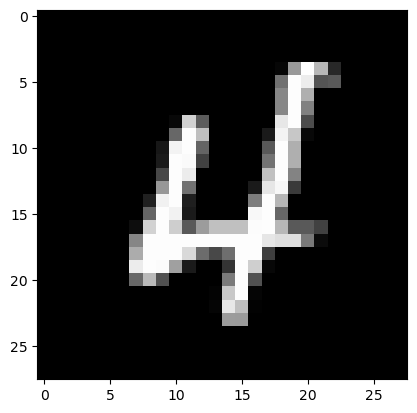

Prediction:  [4]
Label:  0


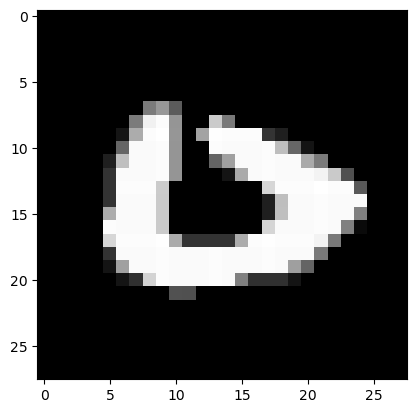

Prediction:  [0]
Label:  0


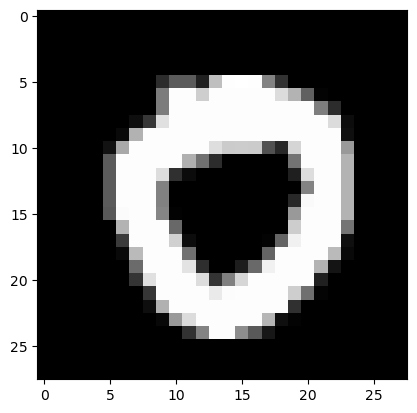

Prediction:  [7]
Label:  7


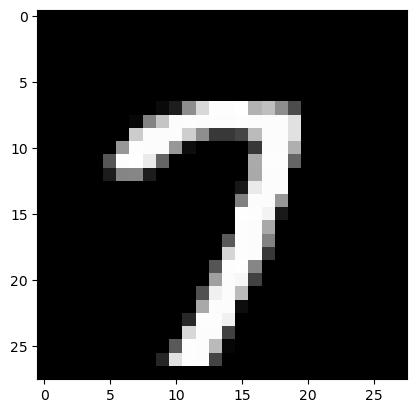

Prediction:  [4]
Label:  4


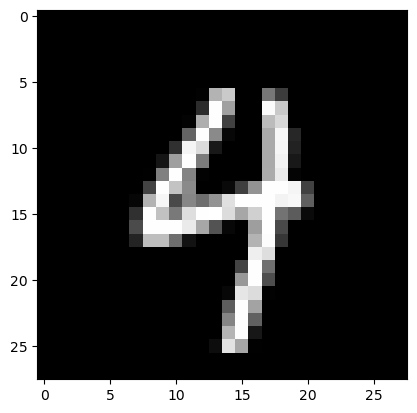

Prediction:  [9]
Label:  9


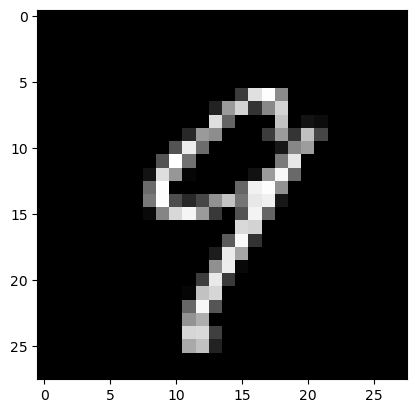

Prediction:  [5]
Label:  5


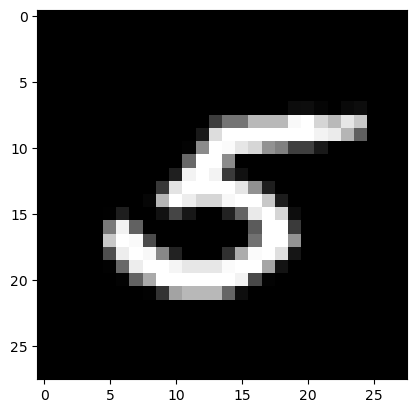

Prediction:  [1]
Label:  1


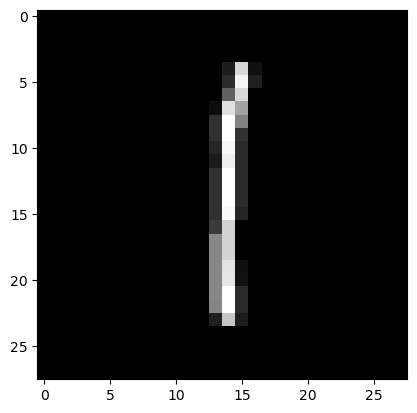

In [56]:
for i in range(10):
    test_prediction(np.random.randint(0, X_train.shape[1]), W1, b1, W2, b2)

In [57]:
test_data = pd.read_csv("../data/mnist_test.csv", header=None)
test_data = np.array(test_data)
m, n = test_data.shape # rows, columns


data_test = test_data.T

Y_test = data_test[0]
X_test = data_test[1:n] / 255

test_predictions = make_predictions(X_test, W1, b1, W2, b2)
get_accuracy(test_predictions, Y_test)

[7 2 1 ... 4 5 6] [7 2 1 ... 4 5 6]


0.9053